<a href="https://colab.research.google.com/github/giankev/lightweight-model-for-signal-processing/blob/main/syntethic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sionna tensorflow matplotlib torch

In [2]:
import tensorflow as tf
import numpy as np
import sionna
import os
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sionna.phy.mapping import Constellation, Mapper
from sionna.phy.channel import AWGN

# Use dataclass for clean configuration
@dataclass(frozen=True)
class RadioSimConfig:
    """
    Configuration for 16-QAM Signal Generation.
    """
    num_examples: int = 20_000     # Training set size
    seq_length: int = 2048          # Shorter sequences train faster (512 or 1024)
    bits_per_symbol: int = 4       # 16-QAM
    
    # SNR Range (dB)
    snr_db_min: float = 5.0        # Harder noise floor
    snr_db_max: float = 25.0       # Clean signals
    
    # Carrier Frequency Offset (CFO)
    # 0.1 rad/sample allows for multiple full rotations per frame
    max_cfo_rad: float = 0.1       
    
    # Random initial phase
    random_phase: bool = True
    
    seed: int = 42

2026-02-25 11:18:21.838727: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 11:18:22.310772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 11:18:24.375933: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
def complex_to_2ch_real(x: tf.Tensor) -> tf.Tensor:
    """Converts [N, L] complex to [N, 2, L] real (PyTorch format: Channels First)."""
    i = tf.math.real(x) # [N, L]
    q = tf.math.imag(x) # [N, L]
    # Stack to [N, 2, L]
    return tf.stack([i, q], axis=1)

def generate_enhanced_dataset(cfg: RadioSimConfig) -> dict:
    """
    Generates synthetic 16-QAM dataset with CFO and AWGN.
    """
    # 1. Setup
    rng = tf.random.Generator.from_seed(cfg.seed)
    constellation = Constellation("qam", cfg.bits_per_symbol)
    mapper = Mapper(constellation=constellation)
    awgn = AWGN()

    N, L = cfg.num_examples, cfg.seq_length
    
    print(f"Generating {N} samples of length {L}...")
    
    # 2. Bits & Symbols
    # Generate random bits
    num_bits = L * cfg.bits_per_symbol
    bits = rng.uniform([N, num_bits], minval=0, maxval=2, dtype=tf.int32)
    
    # Map to complex symbols [N, L]
    x_clean = mapper(bits) 

    # 3. Channel Impairments
    # A. Carrier Frequency Offset (Linear Drift)
    # Random drift per sample: +/- max_cfo_rad
    cfo_rad = rng.uniform([N, 1], minval=-cfg.max_cfo_rad, maxval=cfg.max_cfo_rad, dtype=tf.float32)
    
    # B. Phase Offset (Constant)
    if cfg.random_phase:
        phi_0 = rng.uniform([N, 1], minval=-np.pi, maxval=np.pi, dtype=tf.float32)
    else:
        phi_0 = tf.zeros([N, 1])

    # Time vector [1, L] -> 0, 1, 2...
    t = tf.range(L, dtype=tf.float32)[tf.newaxis, :]
    
    # Phase evolution: theta(t) = (omega * t) + phi_0
    phase_evolution = (cfo_rad * t) + phi_0
    
    # Apply rotation: x_rot = x * e^(j*theta)
    rot_vector = tf.complex(tf.math.cos(phase_evolution), tf.math.sin(phase_evolution))
    x_rotated = x_clean * rot_vector

    # C. AWGN Noise
    snr_db = rng.uniform([N, 1], minval=cfg.snr_db_min, maxval=cfg.snr_db_max, dtype=tf.float32)
    # Sionna AWGN takes noise variance (No), not SNR directly for complex signals.
    # Es = 1 (normalized constellation). SNR = Es / No => No = 1 / 10^(SNR/10)
    no = 1.0 / (10.0 ** (snr_db / 10.0))
    
    # Sionna's AWGN expects noise_power density or variance? 
    # Usually it takes 'noise_power' which matches variance for unit energy signals.
    y_noisy = awgn(x_rotated, no)

    # 4. Format Output
    # PyTorch usually expects [Batch, Channels, Time] -> [N, 2, L]
    iq_clean_real = complex_to_2ch_real(x_clean)
    iq_noisy_real = complex_to_2ch_real(y_noisy)

    return {
        "iq_noisy": iq_noisy_real.numpy().astype(np.float32),
        "iq_clean": iq_clean_real.numpy().astype(np.float32),
        "bits": bits.numpy().astype(np.uint8),
        "cfo_labels": cfo_rad.numpy().astype(np.float32),  # Target for NN
        "phase_labels": phi_0.numpy().astype(np.float32),
        "snr_db": snr_db.numpy().astype(np.float32).flatten()
    }

In [4]:
# Create Config
config = RadioSimConfig()

# Generate
data_dict = generate_enhanced_dataset(config)

# Convert dictionary of numpy arrays to dictionary of torch tensors
torch_data = {k: torch.from_numpy(v) for k, v in data_dict.items()}

# Save
output_path = "./data/radio_data.pth"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
torch.save(torch_data, output_path)

print(f"\n[Success] Dataset saved to: {output_path}")
print(f"Shapes:")
print(f"  Input (Noisy): {torch_data['iq_noisy'].shape}  <- [N, 2, L]")
print(f"  Labels (CFO):  {torch_data['cfo_labels'].shape}")
print(f"  Bits:          {torch_data['bits'].shape}")

E0000 00:00:1772014708.435250    5220 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772014708.445000    5220 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Generating 20000 samples of length 2048...

[Success] Dataset saved to: ./data/radio_data.pth
Shapes:
  Input (Noisy): torch.Size([20000, 2, 2048])  <- [N, 2, L]
  Labels (CFO):  torch.Size([20000, 1])
  Bits:          torch.Size([20000, 8192])


Visualizing generated samples...


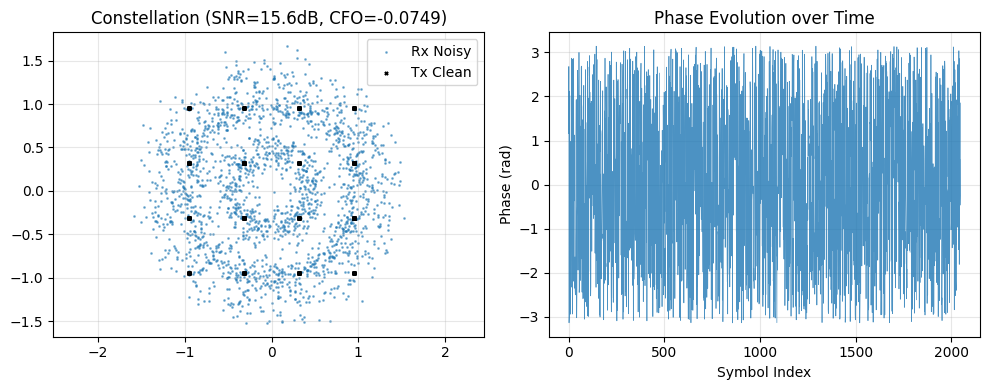

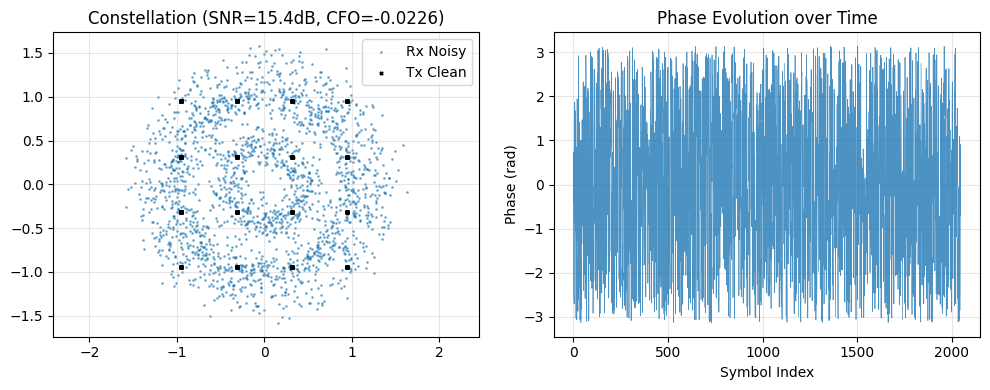

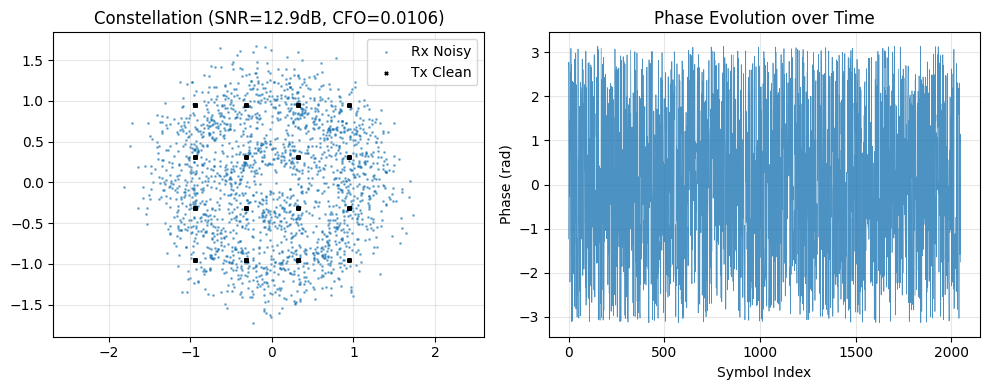

In [5]:
def plot_example(idx, data):
    iq_n = data['iq_noisy'][idx]
    iq_c = data['iq_clean'][idx]
    cfo = data['cfo_labels'][idx].item()
    snr = data['snr_db'][idx].item()
    
    # Convert [2, L] -> Complex [L]
    z_n = iq_n[0] + 1j*iq_n[1]
    z_c = iq_c[0] + 1j*iq_c[1]
    
    plt.figure(figsize=(10, 4))
    
    # 1. Constellation
    plt.subplot(1, 2, 1)
    plt.title(f"Constellation (SNR={snr:.1f}dB, CFO={cfo:.4f})")
    plt.scatter(z_n.real, z_n.imag, s=1, alpha=0.5, label='Rx Noisy')
    plt.scatter(z_c.real, z_c.imag, s=5, c='k', marker='x', label='Tx Clean')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 2. Phase Track (To see the rotation)
    plt.subplot(1, 2, 2)
    plt.title("Phase Evolution over Time")
    plt.plot(np.angle(z_n), lw=0.5, alpha=0.8)
    plt.xlabel("Symbol Index")
    plt.ylabel("Phase (rad)")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot first 3 examples
print("Visualizing generated samples...")
for i in range(3):
    plot_example(i, torch_data)